# Unified markets schema

Minimal Lexis Markets Layer 1 / Layer 2 contract for POC ingest.

**Logical split (no Postgres/MinIO here):**

| Role | Frames | Parquet cache |
| --- | --- | --- |
| Lake (L1) | `obs` | `poc/raw/obs.parquet` |
| Registry (L2) | `series_meta`, `symbol_aliases` | `poc/registry/*.parquet` |

One OHLCV-shaped bar contract across layers — L3 would reuse the same bar fields keyed by `series_id` (out of scope here).

**Immutability:** Layer 1 never splices sources. Overlaps = separate rows keyed by `(source, source_symbol, ts)`.

**Calendar / gaps:** `series_meta.calendar_id` says which sessions should exist (`nyse` vs `fred_native`). Weekends/holidays are not gaps. Zero volume is not automatically a gap — flag in `extras` if useful.

**Ticker ≠ identity:** aliases are time-bounded; don’t force one `series_id` across long dead zones (symbol reuse).

## Schema

### 1. `obs` — Layer 1 lake

| Column | Notes |
| --- | --- |
| `source` | `jacksoncrow` / `jakewright` / `stooq` / `yfinance` / `fred` |
| `source_symbol` | As that source names it |
| `series_type` | `equity` / `etf` / `macro` / … |
| `ts` | Session / observation date |
| `open`,`high`,`low`,`close`,`volume` | Required for equities; NaN OK for FRED (`close` = value) |
| `adj_close` | Crow; Wright null |
| `dividend`,`split` | Wright; else null |
| `currency` | Default `USD` |
| `fetched_at` | Ingest time |
| `extras` | JSON string escape hatch (FRED vintage / units / flags / …) |

### 2. `series_meta` — registry

| Column | Notes |
| --- | --- |
| `series_id` | Stable POC id (not ticker alone) |
| `canonical_symbol` | Display ticker / FRED id |
| `asset_class` | `equity` / `etf` / `macro` / … |
| `exchange`,`country`,`currency` | |
| `calendar_id` | `nyse` / `fred_native` |
| `status` | `ACTIVE` / `DELISTED` / `MERGED` / `RENAMED` / `UNKNOWN` |
| `first_seen`,`last_seen` | |
| `extras` | JSON (name, ETF flag, FRED title/freq, …) |

### 3. `symbol_aliases` — registry

| Column | Notes |
| --- | --- |
| `series_id` | |
| `source`,`source_symbol` | |
| `valid_from`,`valid_to` | Time-bounded |

In [1]:
import json
import os
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import requests
from dotenv import find_dotenv, load_dotenv

ROOT = Path(".").resolve()
JC = ROOT / "jacksoncrow_kaggle"
JW = ROOT / "jakewright_kaggle"
FRED_DIR = ROOT / "fred_api"
POC = ROOT / "poc"
POC_RAW = POC / "raw"
POC_REG = POC / "registry"

OBS_PATH = POC_RAW / "obs.parquet"
META_PATH = POC_REG / "series_meta.parquet"
ALIAS_PATH = POC_REG / "symbol_aliases.parquet"

REBUILD = False

OBS_COLS = [
    "source", "source_symbol", "series_type", "ts",
    "open", "high", "low", "close", "volume",
    "adj_close", "dividend", "split", "currency", "fetched_at", "extras",
]
META_COLS = [
    "series_id", "canonical_symbol", "asset_class", "exchange", "country",
    "currency", "calendar_id", "status", "first_seen", "last_seen", "extras",
]
ALIAS_COLS = ["series_id", "source", "source_symbol", "valid_from", "valid_to"]


def load_csv(p, **kw):
    return pd.read_csv(rf"\\?\{Path(p).resolve()}", **kw)


def require_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    assert not missing, f"{name} missing cols: {missing}"


def extras_json(d):
    return json.dumps(d or {}, default=str)

## Mappers

In [2]:
def to_obs_jacksoncrow(df, symbol, series_type="equity", fetched_at=None):
    fetched_at = fetched_at or datetime.now(timezone.utc)
    out = pd.DataFrame({
        "source": "jacksoncrow",
        "source_symbol": symbol,
        "series_type": series_type,
        "ts": pd.to_datetime(df["Date"]).dt.normalize(),
        "open": df["Open"].astype(float),
        "high": df["High"].astype(float),
        "low": df["Low"].astype(float),
        "close": df["Close"].astype(float),
        "volume": df["Volume"].astype(float),
        "adj_close": df["Adj Close"].astype(float),
        "dividend": pd.NA,
        "split": pd.NA,
        "currency": "USD",
        "fetched_at": fetched_at,
        "extras": extras_json({}),
    })
    return out[OBS_COLS]


def to_obs_jakewright(df, fetched_at=None):
    fetched_at = fetched_at or datetime.now(timezone.utc)
    out = pd.DataFrame({
        "source": "jakewright",
        "source_symbol": df["Ticker"].astype(str),
        "series_type": "equity",  # refined via meta when known
        "ts": pd.to_datetime(df["Date"]).dt.normalize(),
        "open": df["Open"].astype(float),
        "high": df["High"].astype(float),
        "low": df["Low"].astype(float),
        "close": df["Close"].astype(float),
        "volume": df["Volume"].astype(float),
        "adj_close": pd.NA,
        "dividend": df["Dividends"].astype(float),
        "split": df["Stock Splits"].astype(float),
        "currency": "USD",
        "fetched_at": fetched_at,
        "extras": extras_json({}),
    })
    return out[OBS_COLS]


def to_obs_fred(df, series_id, series_type="macro", extras=None, fetched_at=None):
    fetched_at = fetched_at or datetime.now(timezone.utc)
    out = pd.DataFrame({
        "source": "fred",
        "source_symbol": series_id,
        "series_type": series_type,
        "ts": pd.to_datetime(df["date"]).dt.normalize(),
        "open": pd.NA,
        "high": pd.NA,
        "low": pd.NA,
        "close": pd.to_numeric(df["value"], errors="coerce"),
        "volume": pd.NA,
        "adj_close": pd.NA,
        "dividend": pd.NA,
        "split": pd.NA,
        "currency": "USD",
        "fetched_at": fetched_at,
        "extras": extras_json(extras or {}),
    })
    return out[OBS_COLS]


def meta_from_crow(symbol, crow_meta_row, first_seen, last_seen, series_type="equity"):
    r = crow_meta_row
    etf = str(r.get("ETF", "N")).upper() == "Y"
    asset = "etf" if etf else "equity"
    return {
        "series_id": f"{asset}:{symbol}",
        "canonical_symbol": symbol,
        "asset_class": asset,
        "exchange": r.get("Listing Exchange", ""),
        "country": "US",
        "currency": "USD",
        "calendar_id": "nyse",
        "status": "ACTIVE",
        "first_seen": pd.Timestamp(first_seen).normalize(),
        "last_seen": pd.Timestamp(last_seen).normalize(),
        "extras": extras_json({
            "security_name": r.get("Security Name"),
            "etf": etf,
            "nasdaq_traded": r.get("Nasdaq Traded"),
            "market_category": r.get("Market Category"),
        }),
    }


def meta_from_fred_core(row, first_seen, last_seen):
    sid = row["id"]
    return {
        "series_id": f"macro:{sid}",
        "canonical_symbol": sid,
        "asset_class": "macro",
        "exchange": "FRED",
        "country": "US",
        "currency": "USD",
        "calendar_id": "fred_native",
        "status": "ACTIVE",
        "first_seen": pd.Timestamp(first_seen).normalize(),
        "last_seen": pd.Timestamp(last_seen).normalize(),
        "extras": extras_json({
            "label": row.get("label"),
            "title": row.get("title"),
            "frequency": row.get("frequency"),
            "family": row.get("family"),
        }),
    }


def alias_row(series_id, source, source_symbol, valid_from, valid_to):
    return {
        "series_id": series_id,
        "source": source,
        "source_symbol": source_symbol,
        "valid_from": pd.Timestamp(valid_from).normalize() if valid_from is not None else pd.NaT,
        "valid_to": pd.Timestamp(valid_to).normalize() if valid_to is not None else pd.NaT,
    }

## Build or load cache

Demo: **AAPL**, **SPY** from jacksoncrow + jakewright (separate source rows), **DGS10** from FRED.

Set `REBUILD = True` above to remap sources and overwrite `poc/`.

In [3]:
load_dotenv(find_dotenv())

cache_ok = OBS_PATH.exists() and META_PATH.exists() and ALIAS_PATH.exists()

if cache_ok and not REBUILD:
    obs = pd.read_parquet(OBS_PATH)
    series_meta = pd.read_parquet(META_PATH)
    symbol_aliases = pd.read_parquet(ALIAS_PATH)
    print(f"loaded cache  obs={len(obs):,}  meta={len(series_meta)}  aliases={len(symbol_aliases)}")
else:
    now = datetime.now(timezone.utc)
    crow_meta = load_csv(JC / "symbols_valid_meta.csv")
    crow_meta = crow_meta.set_index("Symbol", drop=False)

    # --- equities ---
    equity_specs = [
        ("AAPL", "stocks", "equity"),
        ("SPY", "etfs", "etf"),
    ]
    obs_parts = []
    meta_rows = []
    alias_rows = []

    jw = pd.read_parquet(
        JW / "jakewright_kaggle_all_stock_data.parquet",
        filters=[("Ticker", "in", ["AAPL", "SPY"])],
    )

    for symbol, folder, stype in equity_specs:
        jc_df = load_csv(JC / folder / f"{symbol}.csv", parse_dates=["Date"])
        jc_obs = to_obs_jacksoncrow(jc_df, symbol, series_type=stype, fetched_at=now)
        if stype == "etf":
            jc_obs["series_type"] = "etf"

        jw_sym = jw[jw["Ticker"] == symbol]
        jw_obs = to_obs_jakewright(jw_sym, fetched_at=now)
        jw_obs["series_type"] = stype

        obs_parts.extend([jc_obs, jw_obs])

        first = min(jc_obs["ts"].min(), jw_obs["ts"].min())
        last = max(jc_obs["ts"].max(), jw_obs["ts"].max())
        mrow = meta_from_crow(symbol, crow_meta.loc[symbol], first, last, series_type=stype)
        mrow["asset_class"] = stype
        meta_rows.append(mrow)

        sid = mrow["series_id"]
        alias_rows.append(alias_row(sid, "jacksoncrow", symbol, jc_obs["ts"].min(), jc_obs["ts"].max()))
        alias_rows.append(alias_row(sid, "jakewright", symbol, jw_obs["ts"].min(), jw_obs["ts"].max()))
        alias_rows.append(alias_row(sid, "stooq", f"{symbol.lower()}.us", first, last))

    # --- FRED DGS10 ---
    api_key = os.environ["FRED_API_KEY"]

    def fred_get(path, **params):
        r = requests.get(
            f"https://api.stlouisfed.org/fred/{path}",
            params={**params, "api_key": api_key, "file_type": "json"},
            timeout=60,
        )
        r.raise_for_status()
        return r.json()

    core = pd.read_parquet(FRED_DIR / "fred_athena_core.parquet")
    dgs = core.loc[core["id"] == "DGS10"].iloc[0]
    fred_raw = pd.DataFrame(fred_get("series/observations", series_id="DGS10")["observations"])
    fred_obs = to_obs_fred(
        fred_raw,
        "DGS10",
        extras={
            "units": "percent",
            "frequency": dgs.get("frequency"),
            "realtime_end": "today_default_fred_mode",
            "note": "ALFRED vintage hooks go in extras for Athena as-of later",
        },
        fetched_at=now,
    )
    fred_obs = fred_obs.dropna(subset=["close"])
    obs_parts.append(fred_obs)

    meta_rows.append(meta_from_fred_core(dgs, fred_obs["ts"].min(), fred_obs["ts"].max()))
    alias_rows.append(
        alias_row("macro:DGS10", "fred", "DGS10", fred_obs["ts"].min(), fred_obs["ts"].max())
    )

    obs = pd.concat(obs_parts, ignore_index=True)
    series_meta = pd.DataFrame(meta_rows)[META_COLS]
    symbol_aliases = pd.DataFrame(alias_rows)[ALIAS_COLS]

    require_cols(obs, OBS_COLS, "obs")
    require_cols(series_meta, META_COLS, "series_meta")
    require_cols(symbol_aliases, ALIAS_COLS, "symbol_aliases")

    POC_RAW.mkdir(parents=True, exist_ok=True)
    POC_REG.mkdir(parents=True, exist_ok=True)
    obs.to_parquet(OBS_PATH, index=False)
    series_meta.to_parquet(META_PATH, index=False)
    symbol_aliases.to_parquet(ALIAS_PATH, index=False)
    print(f"wrote cache  obs={len(obs):,}  meta={len(series_meta)}  aliases={len(symbol_aliases)}")

loaded cache  obs=51,961  meta=3  aliases=7


## Display

In [4]:
print("obs by source/symbol:")
display(obs.groupby(["source", "source_symbol", "series_type"], observed=True).size().rename("rows").reset_index())

print("\nobs sample:")
display(obs.head(8))
display(obs.dtypes.to_frame("dtype"))

print("\nseries_meta:")
display(series_meta)

print("\nsymbol_aliases:")
display(symbol_aliases)

obs by source/symbol:


,source,source_symbol,series_type,rows
0,fred,DGS10,macro,16144
1,jacksoncrow,AAPL,equity,9909
2,jacksoncrow,SPY,etf,6843
3,jakewright,AAPL,equity,11066
4,jakewright,SPY,etf,7999



obs sample:


,source,source_symbol,series_type,ts,open,high,low,close,volume,adj_close,dividend,split,currency,fetched_at,extras
0,jacksoncrow,AAPL,equity,1980-12-12,0.513393,0.515625,0.513393,0.513393,117258400.0,0.406782,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}
1,jacksoncrow,AAPL,equity,1980-12-15,0.488839,0.488839,0.486607,0.486607,43971200.0,0.385558,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}
2,jacksoncrow,AAPL,equity,1980-12-16,0.453125,0.453125,0.450893,0.450893,26432000.0,0.357260,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}
3,jacksoncrow,AAPL,equity,1980-12-17,0.462054,0.464286,0.462054,0.462054,21610400.0,0.366103,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}
4,jacksoncrow,AAPL,equity,1980-12-18,0.475446,0.477679,0.475446,0.475446,18362400.0,0.376715,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}
5,jacksoncrow,AAPL,equity,1980-12-19,0.504464,0.506696,0.504464,0.504464,12157600.0,0.399707,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}
6,jacksoncrow,AAPL,equity,1980-12-22,0.529018,0.531250,0.529018,0.529018,9340800.0,0.419162,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}
7,jacksoncrow,AAPL,equity,1980-12-23,0.551339,0.553571,0.551339,0.551339,11737600.0,0.436848,NaN,NaN,USD,2026-08-24 18:34:03.888968+00:00,{}


,dtype
source,str
source_symbol,str
series_type,str
ts,datetime64[us]
open,float64
high,float64
low,float64
close,float64
volume,float64
adj_close,float64



series_meta:


,series_id,canonical_symbol,asset_class,exchange,country,currency,calendar_id,status,first_seen,last_seen,extras
0,equity:AAPL,AAPL,equity,Q,US,USD,nyse,ACTIVE,1980-12-12,2024-11-04,"{""security_name"": ""Apple Inc. - Common Stock"",..."
1,etf:SPY,SPY,etf,P,US,USD,nyse,ACTIVE,1993-01-29,2024-11-04,"{""security_name"": ""SPDR S&P 500"", ""etf"": true,..."
2,macro:DGS10,DGS10,macro,FRED,US,USD,fred_native,ACTIVE,1962-01-02,2026-08-20,"{""label"": ""10Y Treasury"", ""title"": ""Market Yie..."



symbol_aliases:


,series_id,source,source_symbol,valid_from,valid_to
0,equity:AAPL,jacksoncrow,AAPL,1980-12-12,2020-04-01
1,equity:AAPL,jakewright,AAPL,1980-12-12,2024-11-04
2,equity:AAPL,stooq,aapl.us,1980-12-12,2024-11-04
3,etf:SPY,jacksoncrow,SPY,1993-01-29,2020-04-01
4,etf:SPY,jakewright,SPY,1993-01-29,2024-11-04
5,etf:SPY,stooq,spy.us,1993-01-29,2024-11-04
6,macro:DGS10,fred,DGS10,1962-01-02,2026-08-20


## Demo plots

Close (log) for AAPL / SPY by source — separate Layer 1 rows, not stitched. DGS10 from FRED on its own axis.

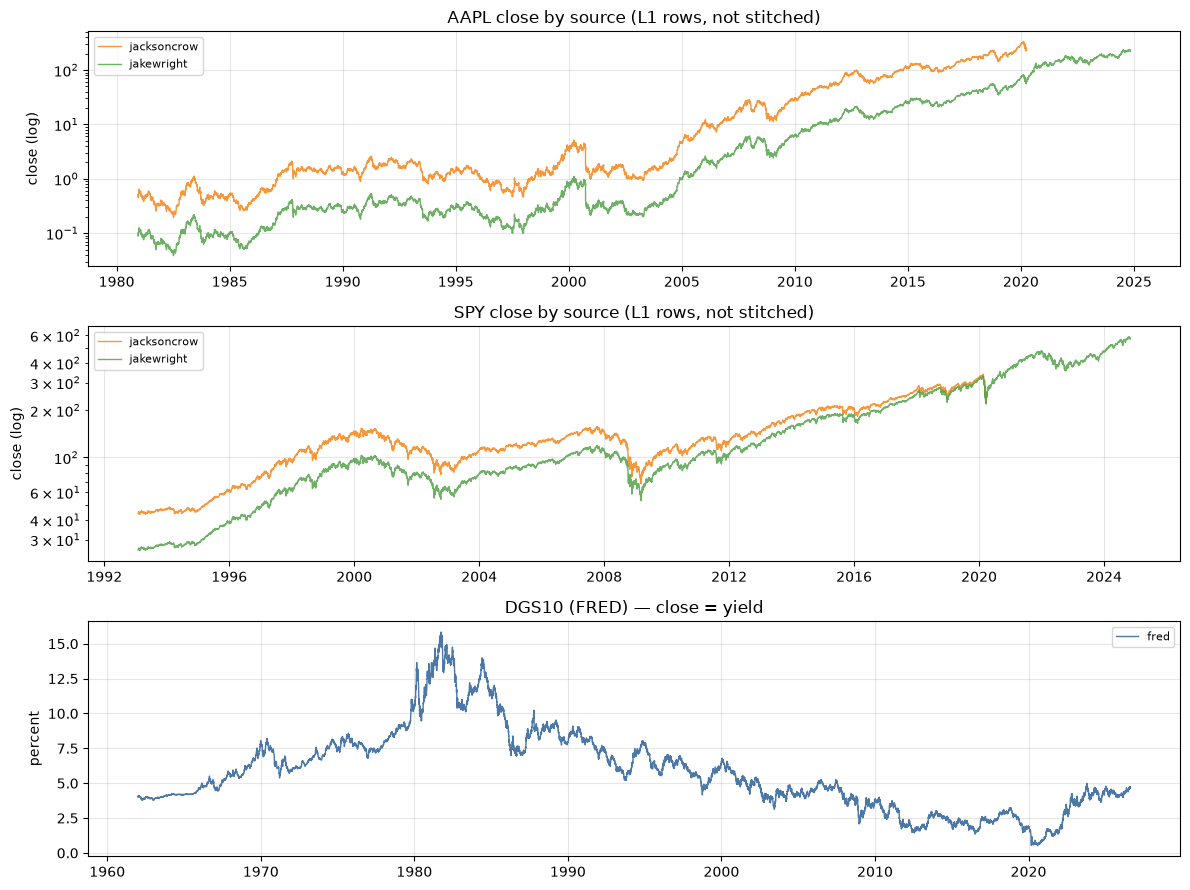

In [5]:
import matplotlib.pyplot as plt

src_color = {
    "jacksoncrow": "#F58518",
    "jakewright": "#54A24B",
    "fred": "#4C78A8",
}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=False)

for ax, symbol in zip(axes[:2], ["AAPL", "SPY"]):
    for src, g in obs.loc[obs["source_symbol"] == symbol].groupby("source", observed=True):
        s = g.sort_values("ts").set_index("ts")["close"]
        ax.plot(s.index, s.values, lw=1.0, alpha=0.85, color=src_color.get(src, "#333"), label=src)
    ax.set_yscale("log")
    ax.set_title(f"{symbol} close by source (L1 rows, not stitched)")
    ax.set_ylabel("close (log)")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

fred = obs.loc[(obs["source"] == "fred") & (obs["source_symbol"] == "DGS10")].sort_values("ts")
axes[2].plot(fred["ts"], fred["close"], lw=1.0, color=src_color["fred"], label="fred")
axes[2].set_title("DGS10 (FRED) — close = yield")
axes[2].set_ylabel("percent")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
